In [ ]:
import subprocess
import os
import sys
sys.path.append("/mnt/c/21_Uni_other/mech/10_py/")
import hdf5_tools as h5t
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from matplotlib.ticker import MultipleLocator
import typing
import pandas as pd
from scipy.interpolate import interp1d

WD="thinLayerNciExtension2D/"       # directory of the testcase
CoCu = "<PathTo>/coreform_cubit.exe"      # cubit executable
CFS =  "<PathTo>/cfs"                 # cfs executable

def get_result(hdf5_file,result,region=None,step='last',multistep=1) :
    """
    read data from a hdf5-file
    
    Parameters
    ----------
    hdf5_file : h5py.File or str
        CFS++ hdf5 data file
    result: string 
        specifies the results to return: e.g. 'accuPressure','mechDisplacement',...
    region: string 
        region name
    step: integer, list, or string  
        defining the step as single integer, list of integersor or 'last' for laststep or
        'all' for all steps
      
    Returns
    -------
    out : ndarray

    Example
    -------
    Extract real data
    >>> U = get_result(Plate3D,'mechDisplacement')
    >>> U[-6:,:]
    array([[ 0.00000000e+00,   0.00000000e+00,   0.00000000e+00],
       	   [-2.01311228e-05,   2.01311228e-05,   2.80932210e-05],
           [-4.28143434e-04,  -4.28143434e-04,   2.07611520e-02],
           [ 4.28143434e-04,  -4.28143434e-04,   2.07611520e-02],
           [-4.28143434e-04,   4.28143434e-04,   2.07611520e-02],
           [ 4.28143434e-04,   4.28143434e-04,   2.07611520e-02]])
    """
    if type(hdf5_file) == str :
        from h5py import File
        with File(hdf5_file,'r') as h5:
            return get_result(h5,result,region,step,multistep)
    else:
        from numpy import array, squeeze
        h5_ms = hdf5_file['Results/Mesh/MultiStep_%i'%multistep] # extract multistep
        if step=='last':
            steps=[last_h5_step(hdf5_file,multistep)]
        elif step=='all' :
            steps=h5_ms['ResultDescription/%s/StepNumbers'%(result)][:]
        elif type(step)==int :
            steps=[step]
        elif hasattr(step, '__iter__') :
            steps=step
        res = []
        for step in steps:
            h5_s = h5_ms['Step_%i'%step] # extract step
            h5_res = h5_s[result] # extract result
            if region==None :
                if len(h5_res.keys())>1 :
                    raise Exception("No region specified but more than one region present for result '"+result+"'in '"+hdf5_file.filename+"', MultiStep_%i, Step_%i"%(multistep,step)+" Available regions: "+", ".join(h5_res.keys()))
                else :
                    region = [k for k in h5_res.keys()][0]
            h5_res_reg = h5_res[region] # extraxt region
            res_type = list(h5_res_reg.keys())[0] # read result type (Nodes or Elements)
            if 'Imag' in h5_res_reg[res_type].keys() :
                res.append( h5_res_reg[res_type]['Real'][:] + 1j*h5_res_reg[res_type]['Imag'][:] )
            else :
                res.append( h5_res_reg[res_type]['Real'][:] )
        return squeeze(array(res))
    
def get_coordinates(hdf5_file,region=None) :
  """
  return nodal coordinates, optional for nodes in a certain region

  Parameters
  ----------
  hdf5_file : h5py.File or str
      CFS++ hdf5 data file
  region : string, optional
      region name for a subset of coordinates

  Returns
  -------
  out : ndarray

  Examples
  --------
  >>> X = get_coordinates(Plate3D)

  # Show coordinates of nodes 2, 4, 6 (index shift) -> X[[1,3,5],:]
  >>> X[[1,3,5],:]
  array([[12. ,   7.2,   0. ],
         [11.5,   4.8,   0. ],
         [ 0.5,   7.2,   0. ]])
  """
  if type(hdf5_file) == str :
    from h5py import File
    with File(hdf5_file,'r') as h5:
      return get_coordinates(h5,region)
  else:
    if not region==None :
      I = hdf5_file['Mesh/Regions/%s'%region]['Nodes'][:] - 1
      return hdf5_file['Mesh/Nodes/Coordinates'][:][I,:]
    else :
      return hdf5_file['Mesh/Nodes/Coordinates'][:]

### run .jou ; get .cdb

TC ... Specifies the Testcase you want to run (just for WD & easy access)  
WD ... Working directory (to append relative paths to)  
CoCu ... Coreform Cubit executable  
CoCu_jou ... .jou file you want to run  

note that: .cdb path must be specified inside .jou

### run simulation.xml ; get results.cfs

CFS ... CFS executable  
XML ... simulation file base name  

(example code, has to be adjusted)

In [ ]:
#subprocess.run([CoCu])       #opens cubit 
CoCu_jou = WD + "mesh.jou"
subprocess.run([CoCu, "-nographics", "-batch", CoCu_jou], cwd=WD, stdout=subprocess.DEVNULL)           #runs the .jou (and creates a .cdb).
os.remove(WD + 'cubit01.jou')                                                                          #idk why this is even created. could be resolved better
#---
XML = "thinLayerNciExtension2D"
subprocess.run([CFS, "-p", f'{XML}.xml', f"job_{XML}"], cwd=WD, check=True, stdout=subprocess.DEVNULL)

### Postprocessing for thinLayerNciExtension2D

Validation:
1) Stiffness $k$ for the thin layer model and the analytical model must fit. 

thin layer simulation: $k \cdot \Delta u = t \rightarrow k_{simulation}   = \frac{t}{\Delta u} = \frac{10^7}{1.25470 \cdot 10^{-6}}=7.970050\cdot 10^{12}$.   
with: t...applied normal traction. $\delta u$...displacement difference across tlr. 

$k_{analytical} = \frac{\mu}{h} \boldsymbol{I} + \frac{\mu + \lambda}{h} \boldsymbol{n} \boldsymbol{n}$

analytical: $k_{analytical} = \frac{2 \mu + \lambda}{h} = \frac{2 \cdot 4.3893e+10 + 7.1615e+10}{0.02} = 7.970050 \cdot 10^{12}$.  
with: $\mu , \lambda$...1st and 2nd Lamé Parameter. h...thickness of tlr.

Error = $\frac{k_{simulation}}{k_{analytical}}-1 = -4.88 \cdot 10^{-14}$

In [6]:
hdf5 = WD + "results_hdf5/job.cfs"
Xl = h5t.get_coordinates(hdf5, region="V_left")[:,:2]
Xr = h5t.get_coordinates(hdf5, region="V_right")[:,:2]
Ul = h5t.get_result(hdf5, 'mechDisplacement', region='V_left', multistep=1)[:,0]
Ur = h5t.get_result(hdf5, 'mechDisplacement', region='V_right', multistep=1)[:,0]

idxl = np.where((Xl[:, 0] == 0.25) & (Xl[:, 1] == 0.05))[0]
idxr = np.where((Xr[:, 0] == 0.25) & (Xr[:, 1] == 0.05))[0]

deltaU = Ur[idxr][0] - Ul[idxl][0]
print(f"DeltaU = {deltaU:.5e}")
k_sim = np.power(10,7)/deltaU
print(f"k_simulation=t/DeltaU {k_sim:.6e}")
k_ana = (2 * 4.3893e10 + 7.1615e10)/(0.02)
print(f"k_analytical = {k_ana:6e}" )
print(f"err = k_simulation/k_analytical = {k_sim/k_ana-1:.2e}")

DeltaU = 1.25470e-06
k_simulation=t/DeltaU 7.970050e+12
k_analytical = 7.970050e+12
err = k_simulation/k_analytical = -4.88e-14


2) comparing the displacements across tlr as shown below.

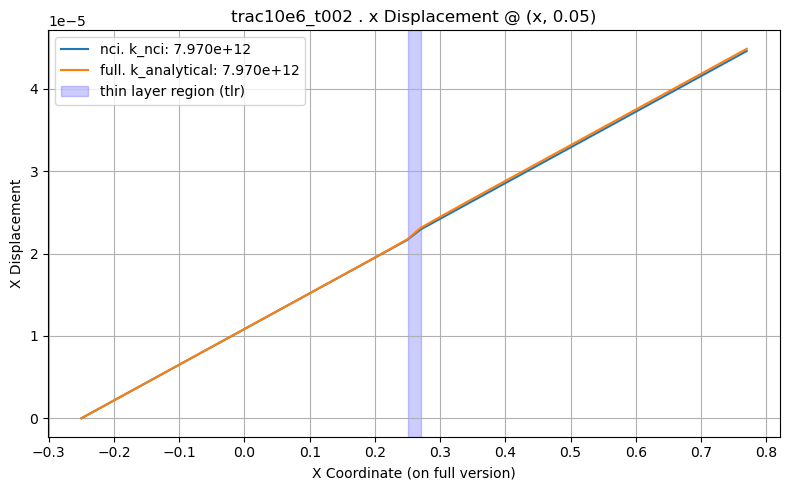

In [10]:
nr  = "trac10e6_t002"
layerThickness = 0.02       # must be same as in .jou mesh file
h = layerThickness

df_nci = pd.read_csv(f"{WD}sensorArray/Disp_nci_{nr}.csv-1")
df_full = pd.read_csv(f"{WD}sensorArray/Disp_full_{nr}.csv-1")

df_nci.loc[df_nci['globCoord-x'] >= 0.25, 'globCoord-x'] += layerThickness       # adjust to fit physical space

# plot displacement across tlr 
fig, ax = plt.subplots(figsize=(8, 5))

line_nci = ax.plot(df_nci['globCoord-x'], df_nci['mechDisplacement-x'], linestyle='-', label=f'nci. k_nci: {k_sim:.3e}')#, marker='o')
line_full = ax.plot(df_full['globCoord-x'], df_full['mechDisplacement-x'], linestyle='-', label=f'full. k_analytical: {k_ana:.3e}')#, marker='x')       #
plt.axvspan(0.25, 0.25+layerThickness, color='blue', alpha=0.2, label="thin layer region (tlr)")

ax.set_xlabel('X Coordinate (on full version)')
ax.set_ylabel('X Displacement')
ax.set_title(f'{nr} . x Displacement @ (x, 0.05)')
ax.xaxis.set_major_locator(MultipleLocator(0.1))

ax.grid(True)
ax.legend()
fig.tight_layout()
# fig.savefig(WD + f"PLT_{nr}.png", dpi=300, bbox_inches="tight")
plt.show()

